In [1]:
# ============================================================
# Car Crash Severity Prediction - Formal EDA
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

sns.set_theme(style="whitegrid")

C:\Users\Zeyad\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
train_path = "car_crash_train.csv"
test_path = "car_crash_test.csv"
sample_submission_path = "sample_submission.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)

In [3]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (4000, 19)
Test shape: (1000, 19)
Sample submission shape: (5000, 2)


In [4]:
display(train.head())
display(test.head())
display(sample_submission.head())

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.0253,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.0024,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.0005,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.1766,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.0657,Other,Morning,Medium,96,Severe Injury


,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,68,61,No,Yes,Rain,Uneven,Rear-end,Truck,5,Worn out,Good,75,17,0.0900,NaN,Night,Low,111,Minor Injury
1,143,13,Yes,Yes,Clear,Dry,Rear-end,Truck,1,Good,Good,41,32,0.0002,Other,Afternoon,Medium,326,Minor Injury
2,147,147,Yes,Yes,Snow,Dry,Rear-end,Sedan,8,Good,Good,21,32,0.0609,NaN,Afternoon,High,462,Minor Injury
3,176,35,Yes,Yes,Fog,Wet,Side impact,Motorcycle,6,Good,Good,49,33,0.1560,NaN,Afternoon,High,399,Severe Injury
4,165,94,Yes,Yes,Rain,Dry,Rear-end,SUV,9,Good,Good,41,38,0.1123,NaN,Morning,Medium,395,Minor Injury


,ID,Predicted_Severity
0,5ca30a05-b855-4cf3-915f-a92a6be7c010,Minor Injury
1,cc90ec30-fbb8-4f72-8814-8df3b82ea995,Severe Injury
2,a35b1df3-d476-4e21-b4be-54356572decb,Fatal
3,3f6e8e90-e5e7-4f49-93b2-64c1970839ce,Fatal
4,68829fcb-2211-40b4-a9a0-d06a8c6c970c,Severe Injury


In [5]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train columns:
['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions', 'Crash Type', 'Vehicle Type', 'Vehicle Age (years)', 'Brake Condition', 'Tire Condition', 'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Distraction Level', 'Time of Day', 'Traffic Density', 'Visibility Distance (m)', 'Severity']

Test columns:
['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions', 'Crash Type', 'Vehicle Type', 'Vehicle Age (years)', 'Brake Condition', 'Tire Condition', 'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Distraction Level', 'Time of Day', 'Traffic Density', 'Visibility Distance (m)', 'Severity']


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       4000 non-null   float

In [7]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         1000 non-null   int64  
 1   Impact Angle (degrees)     1000 non-null   int64  
 2   Airbag Deployed            1000 non-null   object 
 3   Seatbelt Used              1000 non-null   object 
 4   Weather Conditions         1000 non-null   object 
 5   Road Conditions            1000 non-null   object 
 6   Crash Type                 1000 non-null   object 
 7   Vehicle Type               1000 non-null   object 
 8   Vehicle Age (years)        1000 non-null   int64  
 9   Brake Condition            1000 non-null   object 
 10  Tire Condition             1000 non-null   object 
 11  Driver Age                 1000 non-null   int64  
 12  Driver Experience (years)  1000 non-null   int64  
 13  Alcohol Level (BAC%)       1000 non-null   float6

In [8]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Crash Speed (km/h),4000.0000,NaN,NaN,NaN,110.9998,52.2278,20.0000,66.0000,112.0000,157.0000,199.0000
Impact Angle (degrees),4000.0000,NaN,NaN,NaN,89.9797,51.3015,0.0000,45.0000,89.5000,134.0000,179.0000
Airbag Deployed,4000,2,Yes,2817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seatbelt Used,4000,2,Yes,3174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather Conditions,4000,4,Clear,2345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Road Conditions,4000,4,Dry,2792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crash Type,4000,4,Side impact,1413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Type,4000,4,Sedan,1644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Age (years),4000.0000,NaN,NaN,NaN,9.4455,5.7181,0.0000,5.0000,9.0000,14.0000,19.0000
Brake Condition,4000,2,Good,3369,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
target_col = "Severity"

print(train[target_col].value_counts())
print("\nNormalized:")
print(train[target_col].value_counts(normalize=True))

Severity
Minor Injury     2756
Severe Injury    1038
Fatal             206
Name: count, dtype: int64

Normalized:
Severity
Minor Injury    0.6890
Severe Injury   0.2595
Fatal           0.0515
Name: proportion, dtype: float64


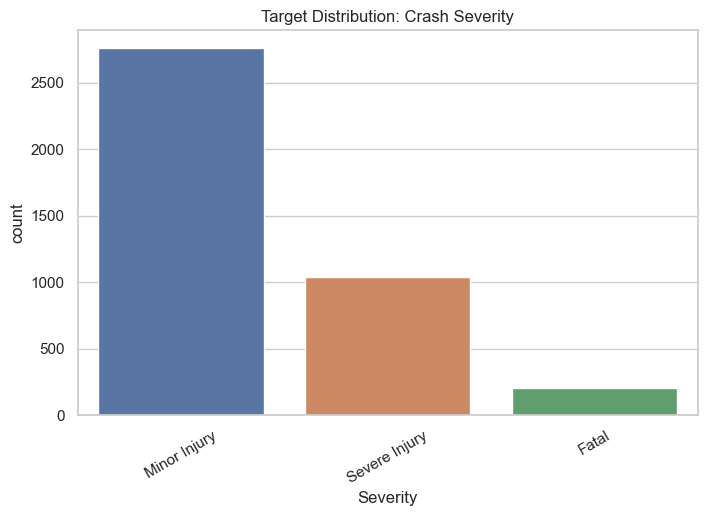

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train, x=target_col, order=train[target_col].value_counts().index)
plt.title("Target Distribution: Crash Severity")
plt.xticks(rotation=30)
plt.show()

# Missing Values

In [11]:
missing_train = train.isnull().sum().sort_values(ascending=False)
missing_test = test.isnull().sum().sort_values(ascending=False)

print("Missing values in train:")
display(missing_train[missing_train > 0])

print("Missing values in test:")
display(missing_test[missing_test > 0])

Missing values in train:


Distraction Level    2360
dtype: int64

Missing values in test:


Distraction Level    603
dtype: int64

# Duplicate Rows

In [12]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in test: 0


# Separate Numerical and Categorical Features

In [13]:
features = [col for col in train.columns if col != target_col]

num_cols = train[features].select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = train[features].select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

print("\nNumber of numerical columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))

Numerical columns: ['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)', 'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Visibility Distance (m)']
Categorical columns: ['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions', 'Crash Type', 'Vehicle Type', 'Brake Condition', 'Tire Condition', 'Distraction Level', 'Time of Day', 'Traffic Density']

Number of numerical columns: 7
Number of categorical columns: 11


# Numerical Feature Distributions

C:\Users\Zeyad\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


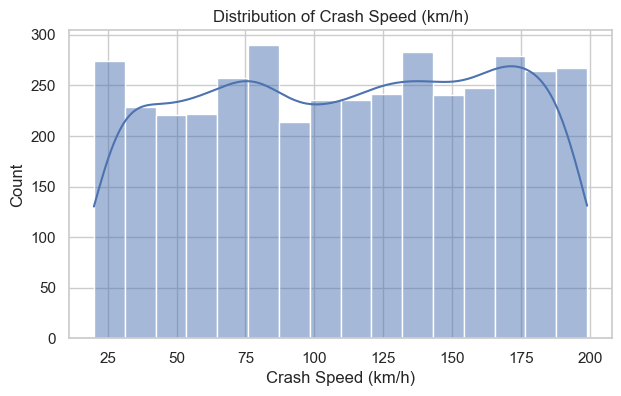

C:\Users\Zeyad\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


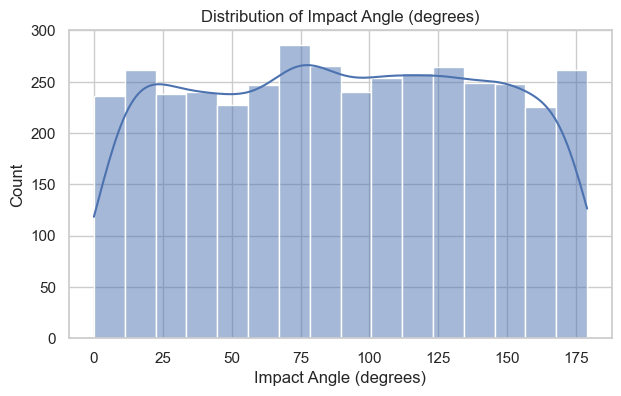

C:\Users\Zeyad\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


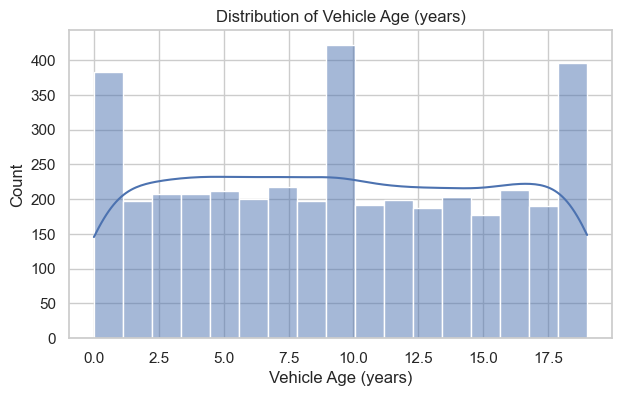

C:\Users\Zeyad\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


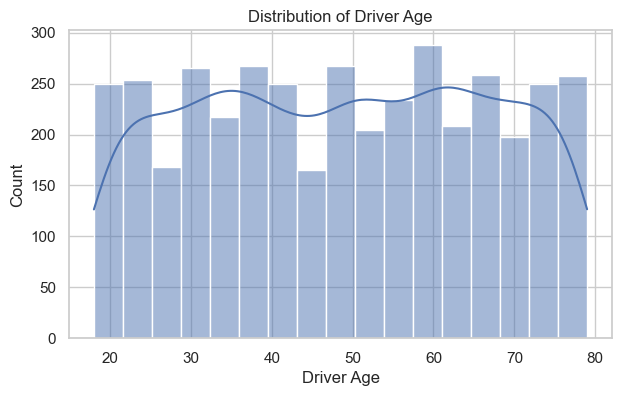

C:\Users\Zeyad\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


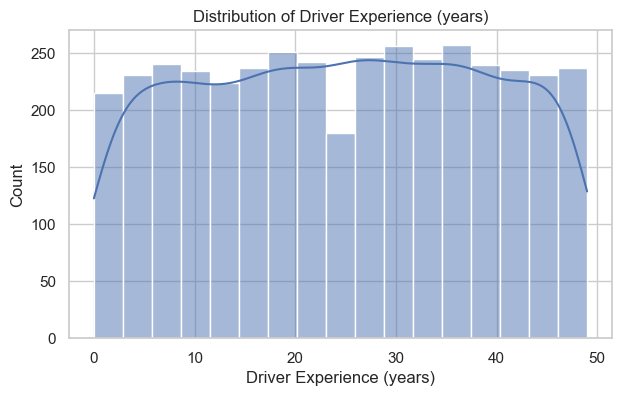

C:\Users\Zeyad\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


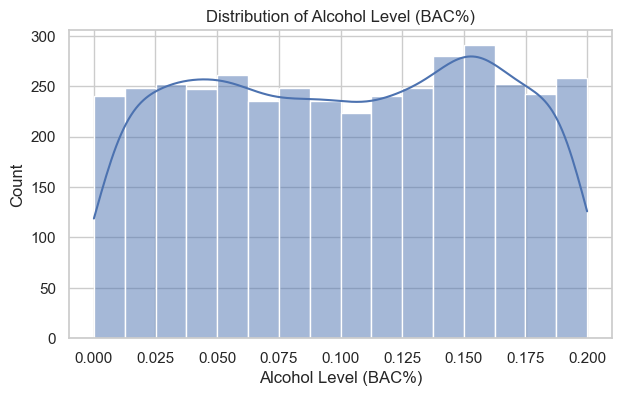

C:\Users\Zeyad\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


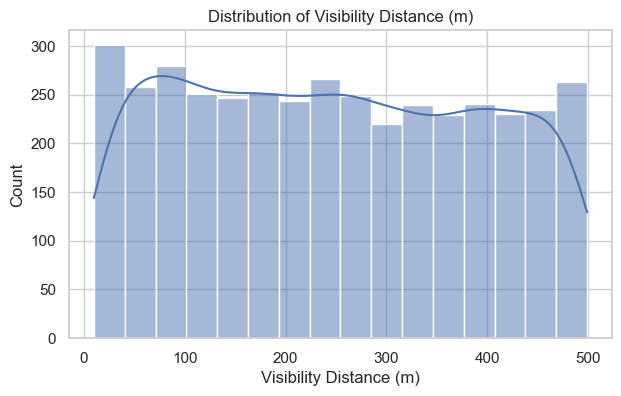

In [14]:
for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(train[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

# Correlation Matrix for Numerical Features

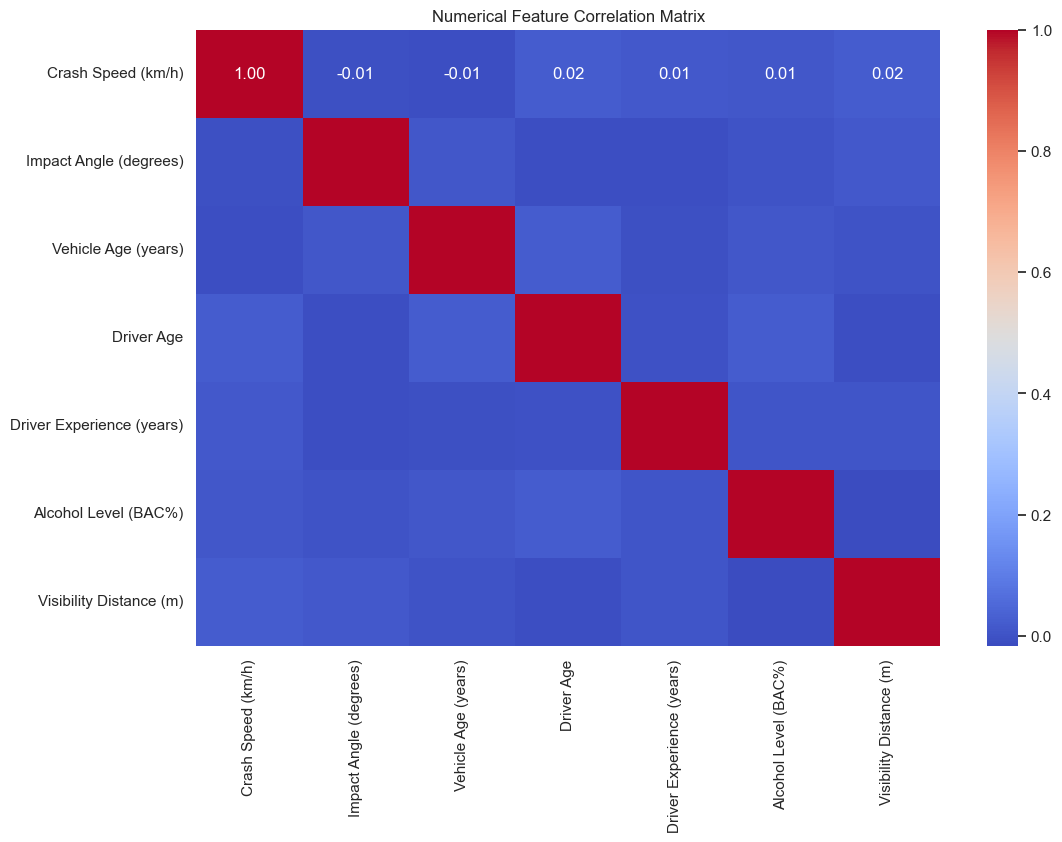

In [15]:
plt.figure(figsize=(12, 8))
corr = train[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numerical Feature Correlation Matrix")
plt.show()

# Check Cardinality of Categorical Features

In [16]:
cat_summary = []

for col in cat_cols:
    cat_summary.append({
        "column": col,
        "unique_values": train[col].nunique(),
        "values": train[col].unique()
    })

cat_summary_df = pd.DataFrame(cat_summary)
display(cat_summary_df)

,column,unique_values,values
0,Airbag Deployed,2,"[Yes, No]"
1,Seatbelt Used,2,"[No, Yes]"
2,Weather Conditions,4,"[Clear, Fog, Rain, Snow]"
3,Road Conditions,4,"[Dry, Icy, Wet, Uneven]"
4,Crash Type,4,"[Rollover, Head-on, Rear-end, Side impact]"
5,Vehicle Type,4,"[Sedan, Truck, SUV, Motorcycle]"
6,Brake Condition,2,"[Good, Worn out]"
7,Tire Condition,2,"[Good, Worn out]"
8,Distraction Level,3,"[nan, Phone, Other, Drowsiness]"
9,Time of Day,3,"[Morning, Afternoon, Night]"


In [17]:
summary = pd.DataFrame({
    "column": train.columns,
    "dtype": train.dtypes.astype(str),
    "missing_count": train.isnull().sum().values,
    "missing_percent": train.isnull().mean().values * 100,
    "unique_values": train.nunique().values
})

summary = summary.sort_values(by="unique_values", ascending=False)
display(summary)

,column,dtype,missing_count,missing_percent,unique_values
Alcohol Level (BAC%),Alcohol Level (BAC%),float64,0,0.0000,4000
Visibility Distance (m),Visibility Distance (m),int64,0,0.0000,489
Crash Speed (km/h),Crash Speed (km/h),int64,0,0.0000,180
Impact Angle (degrees),Impact Angle (degrees),int64,0,0.0000,180
Driver Age,Driver Age,int64,0,0.0000,62
Driver Experience (years),Driver Experience (years),int64,0,0.0000,50
Vehicle Age (years),Vehicle Age (years),int64,0,0.0000,20
Weather Conditions,Weather Conditions,object,0,0.0000,4
Road Conditions,Road Conditions,object,0,0.0000,4
Crash Type,Crash Type,object,0,0.0000,4


# Outlier Check for Numerical Features

In [18]:
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = train[(train[col] < lower) | (train[col] > upper)]

    print(f"{col}")
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Number of outliers:", len(outliers))
    print("-" * 50)

Crash Speed (km/h)
Lower bound: -70.5
Upper bound: 293.5
Number of outliers: 0
--------------------------------------------------
Impact Angle (degrees)
Lower bound: -88.5
Upper bound: 267.5
Number of outliers: 0
--------------------------------------------------
Vehicle Age (years)
Lower bound: -8.5
Upper bound: 27.5
Number of outliers: 0
--------------------------------------------------
Driver Age
Lower bound: -11.0
Upper bound: 109.0
Number of outliers: 0
--------------------------------------------------
Driver Experience (years)
Lower bound: -23.0
Upper bound: 73.0
Number of outliers: 0
--------------------------------------------------
Alcohol Level (BAC%)
Lower bound: -0.10109935005983288
Upper bound: 0.3035124771990402
Number of outliers: 0
--------------------------------------------------
Visibility Distance (m)
Lower bound: -258.0
Upper bound: 750.0
Number of outliers: 0
--------------------------------------------------


In [19]:
print("EDA Initial Conclusions")
print("-" * 60)

print("1. Dataset size:")
print(f"   Train rows: {train.shape[0]}, Train columns: {train.shape[1]}")
print(f"   Test rows: {test.shape[0]}, Test columns: {test.shape[1]}")

print("\n2. Target distribution:")
print(train[target_col].value_counts(normalize=True))

print("\n3. Missing values:")
if train.isnull().sum().sum() == 0:
    print("   No missing values found in train.")
else:
    print(train.isnull().sum()[train.isnull().sum() > 0])

print("\n4. Numerical features:")
print(num_cols)

print("\n5. Categorical features:")
print(cat_cols)

print("\n6. Suggested next step:")
print("   Build baseline models: Logistic Regression, Random Forest, XGBoost/LightGBM/CatBoost.")
print("   Use cross-validation. Do not trust a single train-validation split.")

EDA Initial Conclusions
------------------------------------------------------------
1. Dataset size:
   Train rows: 4000, Train columns: 19
   Test rows: 1000, Test columns: 19

2. Target distribution:
Severity
Minor Injury    0.6890
Severe Injury   0.2595
Fatal           0.0515
Name: proportion, dtype: float64

3. Missing values:
Distraction Level    2360
dtype: int64

4. Numerical features:
['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)', 'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Visibility Distance (m)']

5. Categorical features:
['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions', 'Crash Type', 'Vehicle Type', 'Brake Condition', 'Tire Condition', 'Distraction Level', 'Time of Day', 'Traffic Density']

6. Suggested next step:
   Build baseline models: Logistic Regression, Random Forest, XGBoost/LightGBM/CatBoost.
   Use cross-validation. Do not trust a single train-validation split.


# Data preprocessing 

In [20]:
# ============================================================
# Data Preprocessing
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight

In [21]:
target_col = "Severity"

X = train.drop(columns=[target_col])
y = train[target_col]

# The test file contains Severity, but we must not use it as a feature.
if target_col in test.columns:
    X_test = test.drop(columns=[target_col])
else:
    X_test = test.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (4000, 18)
y shape: (4000,)
X_test shape: (1000, 18)


In [22]:
# X["Distraction_Level_missing"] = X["Distraction Level"].isnull().astype(int)
# X_test["Distraction_Level_missing"] = X_test["Distraction Level"].isnull().astype(int)

In [23]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target encoding:")
for cls, code in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{cls} -> {code}")

Target encoding:
Fatal -> 0
Minor Injury -> 1
Severe Injury -> 2


In [24]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerical columns:")
print(num_cols)

print("\nCategorical columns:")
print(cat_cols)

Numerical columns:
['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)', 'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Visibility Distance (m)']

Categorical columns:
['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions', 'Crash Type', 'Vehicle Type', 'Brake Condition', 'Tire Condition', 'Distraction Level', 'Time of Day', 'Traffic Density']


In [25]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

print("\nTrain target distribution:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nValidation target distribution:")
print(pd.Series(y_valid).value_counts(normalize=True).sort_index())

X_train: (3200, 18)
X_valid: (800, 18)

Train target distribution:
0   0.0516
1   0.6891
2   0.2594
Name: proportion, dtype: float64

Validation target distribution:
0   0.0512
1   0.6887
2   0.2600
Name: proportion, dtype: float64


In [26]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [27]:
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train:", X_train_processed.shape)
print("Processed X_valid:", X_valid_processed.shape)
print("Processed X_test:", X_test_processed.shape)

Processed X_train: (3200, 41)
Processed X_valid: (800, 41)
Processed X_test: (1000, 41)


## Local Test Labels

The uploaded `test` dataset contains a `Severity` column. Since the official Kaggle test set is normally unlabeled, this notebook treats the uploaded test file as a **local test set** for final evaluation only. It is not used for training, preprocessing fitting, validation, or hyperparameter tuning.


In [28]:
# Prepare local test labels only if the uploaded test set contains Severity.
# This is used only for final testing after each model has already been selected.

if target_col in test.columns:
    y_test = test[target_col]
    y_test_encoded = label_encoder.transform(y_test)
    print("Local labeled test set detected.")
    print("y_test shape:", y_test_encoded.shape)
    print("\nTest target distribution:")
    print(pd.Series(y_test).value_counts(normalize=True))
else:
    y_test = None
    y_test_encoded = None
    print("No target labels found in test set. Testing metrics cannot be computed.")


Local labeled test set detected.
y_test shape: (1000,)

Test target distribution:
Severity
Minor Injury    0.7100
Severe Injury   0.2490
Fatal           0.0410
Name: proportion, dtype: float64


In [29]:
# Helper function for local test evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_on_local_test(model_name, model, X_test_data, y_test_data):
    if y_test_data is None:
        test_pred = model.predict(X_test_data)
        print(f"{model_name}: Test labels are not available. Generated predictions only.")
        return test_pred

    test_pred = model.predict(X_test_data)

    print(f"{model_name} Local Test Accuracy:", accuracy_score(y_test_data, test_pred))
    print("\nClassification Report:")
    print(classification_report(
        y_test_data,
        test_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    ))

    cm = confusion_matrix(y_test_data, test_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )

    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"{model_name} Local Test Confusion Matrix")
    plt.show()

    return test_pred


In [30]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
for cls_id, weight in class_weight_dict.items():
    original_label = label_encoder.inverse_transform([cls_id])[0]
    print(f"{original_label}: {weight:.3f}")

Class weights:
Fatal: 6.465
Minor Injury: 0.484
Severe Injury: 1.285


In [31]:
onehot_feature_names = preprocessor.named_transformers_["cat"] \
    .named_steps["onehot"] \
    .get_feature_names_out(cat_cols)

processed_feature_names = num_cols + list(onehot_feature_names)

print("Number of processed features:", len(processed_feature_names))
print(processed_feature_names[:30])

Number of processed features: 41
['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)', 'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Visibility Distance (m)', 'Airbag Deployed_No', 'Airbag Deployed_Yes', 'Seatbelt Used_No', 'Seatbelt Used_Yes', 'Weather Conditions_Clear', 'Weather Conditions_Fog', 'Weather Conditions_Rain', 'Weather Conditions_Snow', 'Road Conditions_Dry', 'Road Conditions_Icy', 'Road Conditions_Uneven', 'Road Conditions_Wet', 'Crash Type_Head-on', 'Crash Type_Rear-end', 'Crash Type_Rollover', 'Crash Type_Side impact', 'Vehicle Type_Motorcycle', 'Vehicle Type_SUV', 'Vehicle Type_Sedan', 'Vehicle Type_Truck', 'Brake Condition_Good', 'Brake Condition_Worn out', 'Tire Condition_Good']


In [32]:
X_train_sample = X_train_processed[:5]

if hasattr(X_train_sample, "toarray"):
    X_train_sample = X_train_sample.toarray()

X_train_sample_df = pd.DataFrame(
    X_train_sample,
    columns=processed_feature_names
)

display(X_train_sample_df)

,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m),Airbag Deployed_No,Airbag Deployed_Yes,Seatbelt Used_No,Seatbelt Used_Yes,Weather Conditions_Clear,Weather Conditions_Fog,Weather Conditions_Rain,Weather Conditions_Snow,Road Conditions_Dry,Road Conditions_Icy,Road Conditions_Uneven,Road Conditions_Wet,Crash Type_Head-on,Crash Type_Rear-end,Crash Type_Rollover,Crash Type_Side impact,Vehicle Type_Motorcycle,Vehicle Type_SUV,Vehicle Type_Sedan,Vehicle Type_Truck,Brake Condition_Good,Brake Condition_Worn out,Tire Condition_Good,Tire Condition_Worn out,Distraction Level_Drowsiness,Distraction Level_Other,Distraction Level_Phone,Distraction Level_Unknown,Time of Day_Afternoon,Time of Day_Morning,Time of Day_Night,Traffic Density_High,Traffic Density_Low,Traffic Density_Medium
0,-1.6095,-1.1498,1.1479,-1.4882,-0.7418,-0.5904,0.4585,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000
1,1.3447,-1.2278,1.6762,1.0862,-0.8821,0.1517,1.4051,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000
2,1.3639,-1.2862,1.6762,-0.8166,-1.3029,0.8119,0.4098,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000
3,-0.6695,0.9150,0.9719,-1.6001,-0.0405,0.3902,-1.4833,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000
4,1.0569,-0.7603,-1.1412,-0.9285,-0.0405,-1.2543,-1.3719,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000


In [33]:
X_train_sample = X_train_processed[:20]

if hasattr(X_train_sample, "toarray"):
    X_train_sample = X_train_sample.toarray()

X_train_sample_df = pd.DataFrame(
    X_train_sample,
    columns=processed_feature_names
)

display(X_train_sample_df.head(20))

,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m),Airbag Deployed_No,Airbag Deployed_Yes,Seatbelt Used_No,Seatbelt Used_Yes,Weather Conditions_Clear,Weather Conditions_Fog,Weather Conditions_Rain,Weather Conditions_Snow,Road Conditions_Dry,Road Conditions_Icy,Road Conditions_Uneven,Road Conditions_Wet,Crash Type_Head-on,Crash Type_Rear-end,Crash Type_Rollover,Crash Type_Side impact,Vehicle Type_Motorcycle,Vehicle Type_SUV,Vehicle Type_Sedan,Vehicle Type_Truck,Brake Condition_Good,Brake Condition_Worn out,Tire Condition_Good,Tire Condition_Worn out,Distraction Level_Drowsiness,Distraction Level_Other,Distraction Level_Phone,Distraction Level_Unknown,Time of Day_Afternoon,Time of Day_Morning,Time of Day_Night,Traffic Density_High,Traffic Density_Low,Traffic Density_Medium
0,-1.6095,-1.1498,1.1479,-1.4882,-0.7418,-0.5904,0.4585,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000
1,1.3447,-1.2278,1.6762,1.0862,-0.8821,0.1517,1.4051,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000
2,1.3639,-1.2862,1.6762,-0.8166,-1.3029,0.8119,0.4098,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000
3,-0.6695,0.9150,0.9719,-1.6001,-0.0405,0.3902,-1.4833,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000
4,1.0569,-0.7603,-1.1412,-0.9285,-0.0405,-1.2543,-1.3719,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000
5,1.3831,-0.9745,0.7958,-1.3203,1.5725,-0.8748,1.5303,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000
6,0.8843,0.6228,0.2675,-0.9285,1.0115,0.9309,-1.3580,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000
7,-1.0532,-0.5070,-1.1412,-0.9285,-1.5133,1.5370,-0.5576,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000
8,-1.4560,-0.0590,0.7958,-1.2643,-0.6016,-1.6726,-1.4972,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000
9,1.0378,0.6617,-0.2608,-0.9285,1.5024,1.5766,1.4051,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000


In [34]:
display(X_train.head(5))
display(X_train_sample_df.head(5))

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m)
2558,27,31,Yes,No,Clear,Dry,Rear-end,Sedan,16,Worn out,Good,22,14,0.0669,Phone,Night,Low,315
2803,181,27,Yes,Yes,Snow,Dry,Side impact,SUV,19,Good,Good,68,12,0.1097,NaN,Afternoon,Low,451
1874,182,24,Yes,No,Clear,Dry,Side impact,Sedan,19,Good,Good,34,6,0.1477,Drowsiness,Morning,Low,308
1867,76,137,Yes,Yes,Clear,Wet,Head-on,SUV,15,Good,Worn out,20,24,0.1234,NaN,Night,Low,36
123,166,51,Yes,Yes,Clear,Dry,Rear-end,Truck,3,Good,Good,32,24,0.0286,NaN,Afternoon,Medium,52


,Crash Speed (km/h),Impact Angle (degrees),Vehicle Age (years),Driver Age,Driver Experience (years),Alcohol Level (BAC%),Visibility Distance (m),Airbag Deployed_No,Airbag Deployed_Yes,Seatbelt Used_No,Seatbelt Used_Yes,Weather Conditions_Clear,Weather Conditions_Fog,Weather Conditions_Rain,Weather Conditions_Snow,Road Conditions_Dry,Road Conditions_Icy,Road Conditions_Uneven,Road Conditions_Wet,Crash Type_Head-on,Crash Type_Rear-end,Crash Type_Rollover,Crash Type_Side impact,Vehicle Type_Motorcycle,Vehicle Type_SUV,Vehicle Type_Sedan,Vehicle Type_Truck,Brake Condition_Good,Brake Condition_Worn out,Tire Condition_Good,Tire Condition_Worn out,Distraction Level_Drowsiness,Distraction Level_Other,Distraction Level_Phone,Distraction Level_Unknown,Time of Day_Afternoon,Time of Day_Morning,Time of Day_Night,Traffic Density_High,Traffic Density_Low,Traffic Density_Medium
0,-1.6095,-1.1498,1.1479,-1.4882,-0.7418,-0.5904,0.4585,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000
1,1.3447,-1.2278,1.6762,1.0862,-0.8821,0.1517,1.4051,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000
2,1.3639,-1.2862,1.6762,-0.8166,-1.3029,0.8119,0.4098,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000
3,-0.6695,0.9150,0.9719,-1.6001,-0.0405,0.3902,-1.4833,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000
4,1.0569,-0.7603,-1.1412,-0.9285,-0.0405,-1.2543,-1.3719,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000


In [35]:
print("Processed train shape:", X_train_processed.shape)
print("Number of feature names:", len(processed_feature_names))

assert X_train_processed.shape[1] == len(processed_feature_names)

Processed train shape: (3200, 41)
Number of feature names: 41


# KNN

In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [37]:
knn_model = KNeighborsClassifier(
    n_neighbors=1,
    weights="uniform",
    metric="minkowski",
    p=2
)

knn_model.fit(X_train_processed, y_train)

KNeighborsClassifier(n_neighbors=1)

In [38]:
y_valid_pred = knn_model.predict(X_valid_processed)

accuracy = accuracy_score(y_valid, y_valid_pred)

print("KNN Validation Accuracy:", accuracy)

KNN Validation Accuracy: 0.5625


In [39]:
print("Classification Report:")

print(classification_report(
    y_valid,
    y_valid_pred,
    target_names=label_encoder.classes_
))

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.08      0.07      0.08        41
 Minor Injury       0.70      0.70      0.70       551
Severe Injury       0.29      0.28      0.28       208

     accuracy                           0.56       800
    macro avg       0.35      0.35      0.35       800
 weighted avg       0.56      0.56      0.56       800



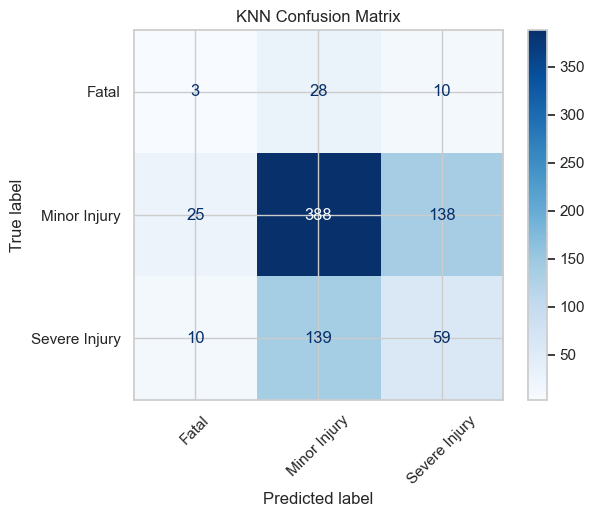

In [40]:
cm = confusion_matrix(y_valid, y_valid_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("KNN Confusion Matrix")
plt.show()

In [41]:
k_values = list(range(1, 31, 2))

results = []

fatal_encoded = label_encoder.transform(["Fatal"])[0]
fatal_key = str(fatal_encoded)

for k in k_values:
    model = KNeighborsClassifier(
        n_neighbors=k,
        weights="uniform",
        metric="minkowski",
        p=2
    )
    
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_valid_processed)
    
    acc = accuracy_score(y_valid, preds)
    
    report = classification_report(
        y_valid,
        preds,
        output_dict=True,
        zero_division=0
    )
    
    results.append({
        "k": k,
        "accuracy": acc,
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "fatal_recall": report[fatal_key]["recall"]
    })

knn_results = pd.DataFrame(results)
display(knn_results.sort_values("macro_f1", ascending=False))

,k,accuracy,macro_f1,weighted_f1,fatal_recall
0,1,0.5625,0.3540,0.5611,0.0732
1,3,0.5813,0.3295,0.5656,0.0488
3,7,0.6663,0.3190,0.5898,0.0000
2,5,0.6362,0.3084,0.5720,0.0000
4,9,0.6675,0.2954,0.5723,0.0000
5,11,0.6687,0.2912,0.5696,0.0000
8,17,0.6875,0.2865,0.5725,0.0000
6,13,0.6713,0.2843,0.5654,0.0000
7,15,0.6763,0.2776,0.5621,0.0000
10,21,0.6863,0.2775,0.5655,0.0000


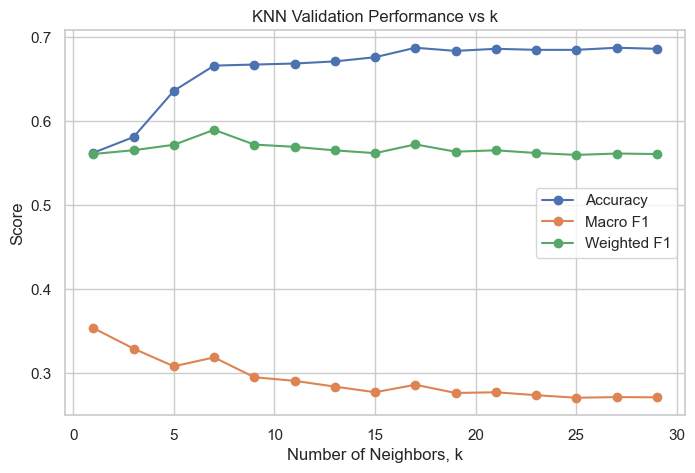

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(knn_results["k"], knn_results["accuracy"], marker="o", label="Accuracy")
plt.plot(knn_results["k"], knn_results["macro_f1"], marker="o", label="Macro F1")
plt.plot(knn_results["k"], knn_results["weighted_f1"], marker="o", label="Weighted F1")
plt.xlabel("Number of Neighbors, k")
plt.ylabel("Score")
plt.title("KNN Validation Performance vs k")
plt.legend()
plt.grid(True)
plt.show()

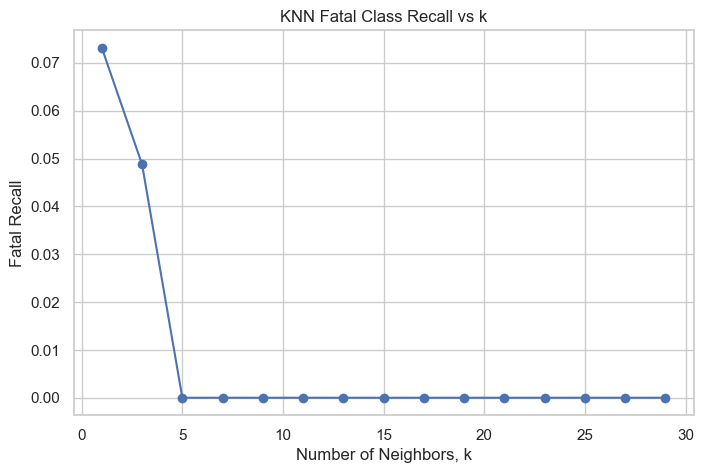

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(knn_results["k"], knn_results["fatal_recall"], marker="o")
plt.xlabel("Number of Neighbors, k")
plt.ylabel("Fatal Recall")
plt.title("KNN Fatal Class Recall vs k")
plt.grid(True)
plt.show()

In [44]:
k_values = list(range(1, 31, 2))

weighted_results = []

fatal_encoded = label_encoder.transform(["Fatal"])[0]
fatal_key = str(fatal_encoded)

for k in k_values:
    model = KNeighborsClassifier(
        n_neighbors=k,
        weights="distance",
        metric="minkowski",
        p=2
    )
    
    model.fit(X_train_processed, y_train)
    preds = model.predict(X_valid_processed)
    
    acc = accuracy_score(y_valid, preds)
    
    report = classification_report(
        y_valid,
        preds,
        output_dict=True,
        zero_division=0
    )
    
    weighted_results.append({
        "k": k,
        "accuracy": acc,
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "fatal_recall": report[fatal_key]["recall"]
    })

knn_weighted_results = pd.DataFrame(weighted_results)
display(knn_weighted_results.sort_values("macro_f1", ascending=False))

,k,accuracy,macro_f1,weighted_f1,fatal_recall
0,1,0.5625,0.3540,0.5611,0.0732
1,3,0.6038,0.3401,0.5770,0.0244
3,7,0.6538,0.3177,0.5847,0.0000
2,5,0.6350,0.3143,0.5755,0.0000
4,9,0.6650,0.3037,0.5779,0.0000
5,11,0.6700,0.2939,0.5720,0.0000
8,17,0.6837,0.2881,0.5725,0.0000
6,13,0.6675,0.2857,0.5652,0.0000
9,19,0.6825,0.2821,0.5674,0.0000
7,15,0.6687,0.2809,0.5621,0.0000


In [45]:
best_uniform = knn_results.sort_values("macro_f1", ascending=False).iloc[0]
best_weighted = knn_weighted_results.sort_values("macro_f1", ascending=False).iloc[0]

print("Best uniform KNN:")
print(best_uniform)

print("\nBest distance-weighted KNN:")
print(best_weighted)

Best uniform KNN:
k              1.0000
accuracy       0.5625
macro_f1       0.3540
weighted_f1    0.5611
fatal_recall   0.0732
Name: 0, dtype: float64

Best distance-weighted KNN:
k              1.0000
accuracy       0.5625
macro_f1       0.3540
weighted_f1    0.5611
fatal_recall   0.0732
Name: 0, dtype: float64


In [46]:
if best_weighted["macro_f1"] >= best_uniform["macro_f1"]:
    best_k = int(best_weighted["k"])
    best_weights = "distance"
else:
    best_k = int(best_uniform["k"])
    best_weights = "uniform"

print("Selected KNN:")
print("k =", best_k)
print("weights =", best_weights)

Selected KNN:
k = 1
weights = distance


In [47]:
best_knn_model = KNeighborsClassifier(
    n_neighbors=best_k,
    weights=best_weights,
    metric="minkowski",
    p=2
)

best_knn_model.fit(X_train_processed, y_train)

y_valid_pred_best = best_knn_model.predict(X_valid_processed)

print("Best KNN Accuracy:", accuracy_score(y_valid, y_valid_pred_best))

print(classification_report(
    y_valid,
    y_valid_pred_best,
    target_names=label_encoder.classes_,
    zero_division=0
))

Best KNN Accuracy: 0.5625
               precision    recall  f1-score   support

        Fatal       0.08      0.07      0.08        41
 Minor Injury       0.70      0.70      0.70       551
Severe Injury       0.29      0.28      0.28       208

     accuracy                           0.56       800
    macro avg       0.35      0.35      0.35       800
 weighted avg       0.56      0.56      0.56       800



## KNN Testing Phase


KNN Local Test Accuracy: 0.561

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.05      0.07      0.06        41
 Minor Injury       0.71      0.71      0.71       710
Severe Injury       0.23      0.22      0.22       249

     accuracy                           0.56      1000
    macro avg       0.33      0.33      0.33      1000
 weighted avg       0.56      0.56      0.56      1000



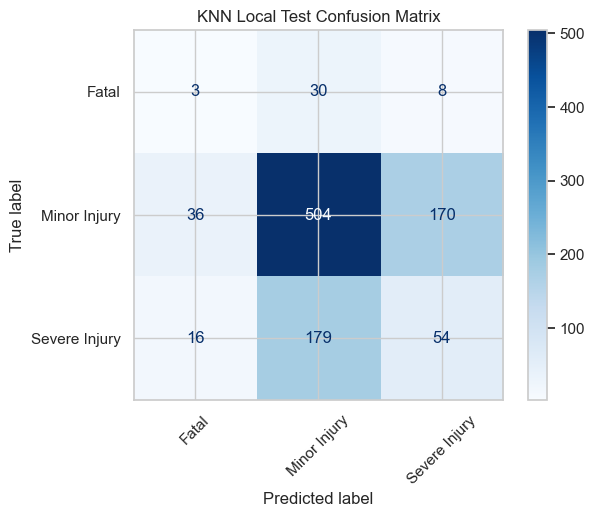

In [48]:
# Final local test evaluation for the selected KNN model.
# The test set is used only here, after model selection using the validation set.

y_test_pred_knn = evaluate_on_local_test(
    "KNN",
    best_knn_model,
    X_test_processed,
    y_test_encoded
)


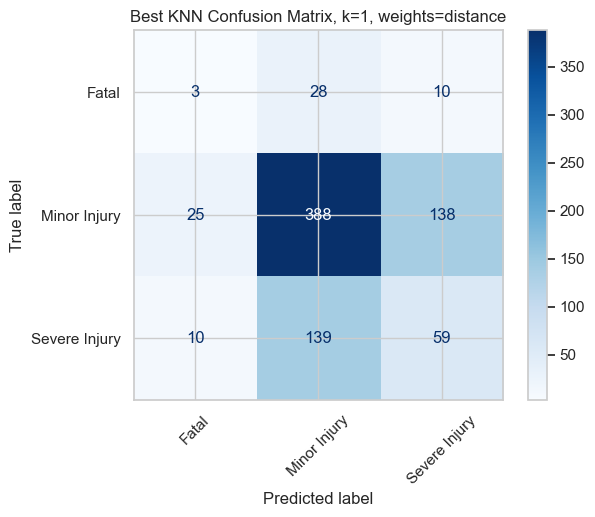

In [49]:
cm = confusion_matrix(y_valid, y_valid_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Best KNN Confusion Matrix, k={best_k}, weights={best_weights}")
plt.show()

# Commen on KNN results

The KNN model achieved a validation accuracy of 56.25%, but this result is mainly driven by the dominant Minor Injury class. The class-wise results show that the model performs reasonably on Minor Injury with an F1-score of 0.70, but performs poorly on the minority and safety-critical classes. Fatal accidents have an F1-score of only 0.08, while Severe Injury has an F1-score of 0.28. The low macro F1-score of 0.35 indicates that the model is not balanced across classes and struggles to identify severe outcomes. Therefore, accuracy alone is not a reliable metric for this task, and macro F1-score should be prioritized when comparing models.


# Decision Tree

In [50]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [51]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight=class_weight_dict
)

dt_model.fit(X_train_processed, y_train)

DecisionTreeClassifier(class_weight={0: 6.4646464646464645,
                                     1: 0.4837490551776266,
                                     2: 1.285140562248996},
                       random_state=42)

In [52]:
y_valid_pred_dt = dt_model.predict(X_valid_processed)

print("Decision Tree Validation Accuracy:", accuracy_score(y_valid, y_valid_pred_dt))

print("\nClassification Report:")
print(classification_report(
    y_valid,
    y_valid_pred_dt,
    target_names=label_encoder.classes_,
    zero_division=0
))

Decision Tree Validation Accuracy: 0.545

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.05      0.05      0.05        41
 Minor Injury       0.69      0.69      0.69       551
Severe Injury       0.27      0.26      0.27       208

     accuracy                           0.55       800
    macro avg       0.33      0.33      0.33       800
 weighted avg       0.54      0.55      0.54       800



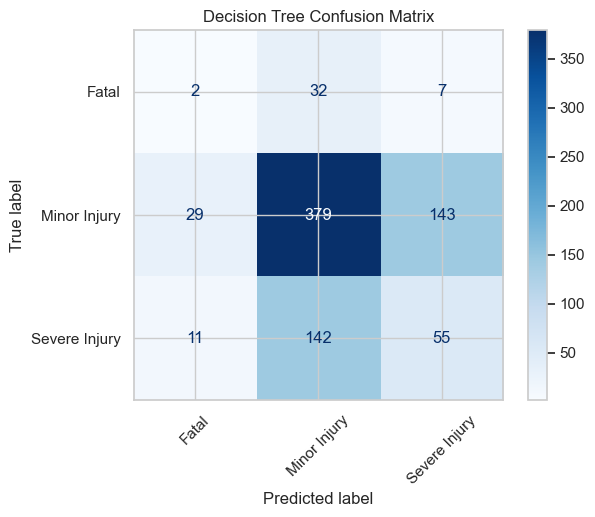

In [53]:
cm = confusion_matrix(y_valid, y_valid_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [54]:
train_pred_dt = dt_model.predict(X_train_processed)
valid_pred_dt = dt_model.predict(X_valid_processed)

train_acc = accuracy_score(y_train, train_pred_dt)
valid_acc = accuracy_score(y_valid, valid_pred_dt)

print("Training Accuracy:", train_acc)
print("Validation Accuracy:", valid_acc)
print("Gap:", train_acc - valid_acc)

Training Accuracy: 1.0
Validation Accuracy: 0.545
Gap: 0.45499999999999996


In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
import pandas as pd
import numpy as np

results = []

max_depth_values = [2, 3, 4, 5, 6, 7, 8, 10]
min_samples_leaf_values = [5, 10, 20, 30, 50, 75, 100]
min_samples_split_values = [10, 20, 50, 100, 150]

for max_depth in max_depth_values:
    for min_samples_leaf in min_samples_leaf_values:
        for min_samples_split in min_samples_split_values:

            model = DecisionTreeClassifier(
                random_state=42,
                class_weight=class_weight_dict,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                min_samples_split=min_samples_split
            )

            model.fit(X_train_processed, y_train)

            train_pred = model.predict(X_train_processed)
            valid_pred = model.predict(X_valid_processed)

            train_acc = accuracy_score(y_train, train_pred)
            valid_acc = accuracy_score(y_valid, valid_pred)

            macro_f1 = f1_score(y_valid, valid_pred, average="macro")
            weighted_f1 = f1_score(y_valid, valid_pred, average="weighted")

            results.append({
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf,
                "min_samples_split": min_samples_split,
                "train_accuracy": train_acc,
                "valid_accuracy": valid_acc,
                "gap": train_acc - valid_acc,
                "macro_f1": macro_f1,
                "weighted_f1": weighted_f1
            })

dt_tuning_results = pd.DataFrame(results)

display(
    dt_tuning_results
    .sort_values(["macro_f1", "valid_accuracy"], ascending=False)
    .head(20)
)

,max_depth,min_samples_leaf,min_samples_split,train_accuracy,valid_accuracy,gap,macro_f1,weighted_f1
130,5,75,10,0.3697,0.3425,0.0272,0.2961,0.3876
131,5,75,20,0.3697,0.3425,0.0272,0.2961,0.3876
132,5,75,50,0.3697,0.3425,0.0272,0.2961,0.3876
133,5,75,100,0.3697,0.3425,0.0272,0.2961,0.3876
134,5,75,150,0.3697,0.3425,0.0272,0.2961,0.3876
129,5,50,150,0.3872,0.3500,0.0372,0.2917,0.3910
246,10,5,20,0.5022,0.3513,0.1509,0.2902,0.4213
124,5,30,150,0.3991,0.3525,0.0466,0.2901,0.3975
120,5,30,10,0.3937,0.3500,0.0438,0.2897,0.3999
121,5,30,20,0.3937,0.3500,0.0438,0.2897,0.3999


In [56]:
sane_dt_results = dt_tuning_results[
    dt_tuning_results["gap"] < 0.15
].copy()

display(
    sane_dt_results
    .sort_values(["macro_f1", "valid_accuracy"], ascending=False)
    .head(10)
)

,max_depth,min_samples_leaf,min_samples_split,train_accuracy,valid_accuracy,gap,macro_f1,weighted_f1
130,5,75,10,0.3697,0.3425,0.0272,0.2961,0.3876
131,5,75,20,0.3697,0.3425,0.0272,0.2961,0.3876
132,5,75,50,0.3697,0.3425,0.0272,0.2961,0.3876
133,5,75,100,0.3697,0.3425,0.0272,0.2961,0.3876
134,5,75,150,0.3697,0.3425,0.0272,0.2961,0.3876
129,5,50,150,0.3872,0.3500,0.0372,0.2917,0.3910
124,5,30,150,0.3991,0.3525,0.0466,0.2901,0.3975
120,5,30,10,0.3937,0.3500,0.0438,0.2897,0.3999
121,5,30,20,0.3937,0.3500,0.0438,0.2897,0.3999
122,5,30,50,0.3937,0.3500,0.0438,0.2897,0.3999


In [57]:
best_dt_row = sane_dt_results.sort_values("macro_f1", ascending=False).iloc[0]

best_dt_row

max_depth            5.0000
min_samples_leaf    75.0000
min_samples_split   20.0000
train_accuracy       0.3697
valid_accuracy       0.3425
gap                  0.0272
macro_f1             0.2961
weighted_f1          0.3876
Name: 131, dtype: float64

In [58]:
best_row = sane_dt_results.sort_values(
    ["macro_f1", "valid_accuracy"], 
    ascending=False
).iloc[0]

best_dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight=class_weight_dict,
    max_depth=int(best_row["max_depth"]),
    min_samples_leaf=int(best_row["min_samples_leaf"]),
    min_samples_split=int(best_row["min_samples_split"])
)

best_dt_model.fit(X_train_processed, y_train)

y_valid_pred_best_dt = best_dt_model.predict(X_valid_processed)

print("Best pruned Decision Tree")
print("max_depth:", best_row["max_depth"])
print("min_samples_leaf:", best_row["min_samples_leaf"])
print("min_samples_split:", best_row["min_samples_split"])

print("\nValidation Accuracy:", accuracy_score(y_valid, y_valid_pred_best_dt))
print("\nClassification Report:")
print(classification_report(
    y_valid,
    y_valid_pred_best_dt,
    target_names=label_encoder.classes_,
    zero_division=0
))


Best pruned Decision Tree
max_depth: 5.0
min_samples_leaf: 75.0
min_samples_split: 10.0

Validation Accuracy: 0.3425

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.07      0.46      0.13        41
 Minor Injury       0.68      0.31      0.43       551
Severe Injury       0.28      0.40      0.33       208

     accuracy                           0.34       800
    macro avg       0.35      0.39      0.30       800
 weighted avg       0.55      0.34      0.39       800



## Decision Tree Testing Phase


Decision Tree Local Test Accuracy: 0.329

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.03      0.24      0.05        41
 Minor Injury       0.72      0.33      0.45       710
Severe Injury       0.25      0.35      0.29       249

     accuracy                           0.33      1000
    macro avg       0.33      0.31      0.26      1000
 weighted avg       0.57      0.33      0.39      1000



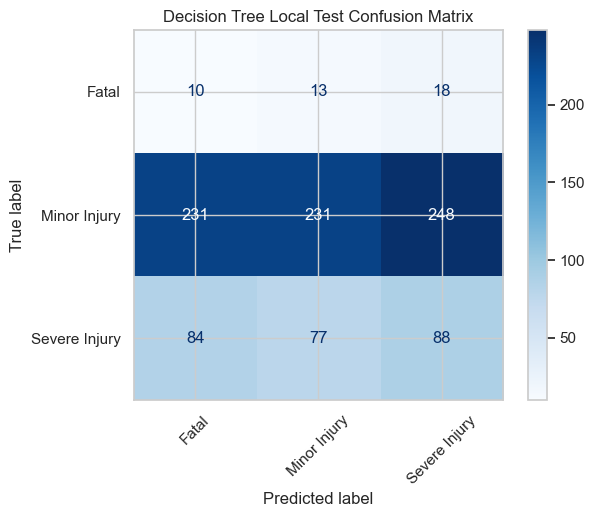

In [59]:
# Final local test evaluation for the selected pruned Decision Tree model.

y_test_pred_dt = evaluate_on_local_test(
    "Decision Tree",
    best_dt_model,
    X_test_processed,
    y_test_encoded
)


# Comment on Decision Tree results

The pruned Decision Tree achieved a validation accuracy of 34.25%, which is lower than the KNN model. This drop in accuracy occurs because the tree predicts the minority classes more often instead of mainly favoring the dominant Minor Injury class. The Fatal class recall improved to 0.46, meaning the model detects more fatal cases, but its precision is only 0.07, indicating many false Fatal predictions. The Severe Injury recall also improved to 0.40, but the F1-score remains low at 0.33. Meanwhile, Minor Injury recall dropped to 0.31, which significantly reduces the overall accuracy. Therefore, this Decision Tree is more sensitive to minority classes than KNN, but it is still not a strong model because it has poor precision and a low macro F1-score of 0.30.

# Random Forest

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [61]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight=class_weight_dict,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(class_weight={0: 6.4646464646464645,
                                     1: 0.4837490551776266,
                                     2: 1.285140562248996},
                       n_estimators=300, n_jobs=-1, random_state=42)

In [62]:
y_train_pred_rf = rf_model.predict(X_train_processed)
y_valid_pred_rf = rf_model.predict(X_valid_processed)

train_acc = accuracy_score(y_train, y_train_pred_rf)
valid_acc = accuracy_score(y_valid, y_valid_pred_rf)

print("Random Forest Training Accuracy:", train_acc)
print("Random Forest Validation Accuracy:", valid_acc)
print("Gap:", train_acc - valid_acc)

print("\nClassification Report:")
print(classification_report(
    y_valid,
    y_valid_pred_rf,
    target_names=label_encoder.classes_,
    zero_division=0
))

Random Forest Training Accuracy: 1.0
Random Forest Validation Accuracy: 0.68875
Gap: 0.31125

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.69      1.00      0.82       551
Severe Injury       0.00      0.00      0.00       208

     accuracy                           0.69       800
    macro avg       0.23      0.33      0.27       800
 weighted avg       0.47      0.69      0.56       800



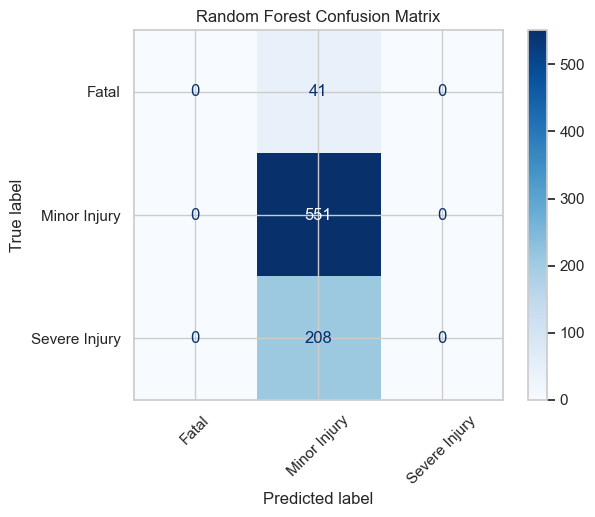

In [63]:
cm = confusion_matrix(y_valid, y_valid_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [64]:
rf_results = []

n_estimators_values = [200, 300]
max_depth_values = [8, 10, 12, 15, None]
min_samples_leaf_values = [1, 2, 5, 10]
max_features_values = ["sqrt", "log2"]

fatal_encoded = label_encoder.transform(["Fatal"])[0]
fatal_key = str(fatal_encoded)

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        for min_samples_leaf in min_samples_leaf_values:
            for max_features in max_features_values:
                
                model = RandomForestClassifier(
                    n_estimators=n_estimators,
                    random_state=42,
                    class_weight=class_weight_dict,
                    max_depth=max_depth,
                    min_samples_split=5,
                    min_samples_leaf=min_samples_leaf,
                    max_features=max_features,
                    n_jobs=-1
                )
                
                model.fit(X_train_processed, y_train)
                
                train_preds = model.predict(X_train_processed)
                valid_preds = model.predict(X_valid_processed)
                
                train_acc = accuracy_score(y_train, train_preds)
                valid_acc = accuracy_score(y_valid, valid_preds)
                
                report = classification_report(
                    y_valid,
                    valid_preds,
                    output_dict=True,
                    zero_division=0
                )
                
                rf_results.append({
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "max_features": max_features,
                    "train_accuracy": train_acc,
                    "valid_accuracy": valid_acc,
                    "gap": train_acc - valid_acc,
                    "macro_f1": report["macro avg"]["f1-score"],
                    "weighted_f1": report["weighted avg"]["f1-score"],
                    "fatal_precision": report[fatal_key]["precision"],
                    "fatal_recall": report[fatal_key]["recall"],
                    "fatal_f1": report[fatal_key]["f1-score"]
                })

rf_results_df = pd.DataFrame(rf_results)

display(
    rf_results_df
    .sort_values(["macro_f1", "valid_accuracy"], ascending=False)
    .head(20)
)

,n_estimators,max_depth,min_samples_leaf,max_features,train_accuracy,valid_accuracy,gap,macro_f1,weighted_f1,fatal_precision,fatal_recall,fatal_f1
5,200,8.0000,5,log2,0.9453,0.6462,0.2991,0.3393,0.5891,0.1429,0.0244,0.0417
47,300,8.0000,10,log2,0.9097,0.5975,0.3122,0.3295,0.5577,0.2000,0.0488,0.0784
7,200,8.0000,10,log2,0.8938,0.6075,0.2863,0.3210,0.5647,0.0769,0.0244,0.0370
6,200,8.0000,10,sqrt,0.9028,0.5962,0.3066,0.3191,0.5590,0.0625,0.0244,0.0351
45,300,8.0000,5,log2,0.9519,0.6475,0.3044,0.3124,0.5791,0.0000,0.0000,0.0000
4,200,8.0000,5,sqrt,0.9519,0.6288,0.3231,0.3107,0.5642,0.0909,0.0244,0.0385
79,300,NaN,10,log2,0.9750,0.6525,0.3225,0.3093,0.5778,0.0000,0.0000,0.0000
14,200,10.0000,10,sqrt,0.9550,0.6200,0.3350,0.3092,0.5666,0.0000,0.0000,0.0000
39,200,NaN,10,log2,0.9700,0.6512,0.3187,0.3068,0.5751,0.0000,0.0000,0.0000
62,300,12.0000,10,sqrt,0.9697,0.6450,0.3247,0.3063,0.5725,0.0000,0.0000,0.0000


In [65]:
best_rf_row = rf_results_df.sort_values(
    ["macro_f1", "valid_accuracy"],
    ascending=False
).iloc[0]

best_rf_row

n_estimators          200
max_depth          8.0000
min_samples_leaf        5
max_features         log2
train_accuracy     0.9453
valid_accuracy     0.6462
gap                0.2991
macro_f1           0.3393
weighted_f1        0.5891
fatal_precision    0.1429
fatal_recall       0.0244
fatal_f1           0.0417
Name: 5, dtype: object

In [66]:
best_rf_model = RandomForestClassifier(
    n_estimators=int(best_rf_row["n_estimators"]),
    random_state=42,
    class_weight=class_weight_dict,
    max_depth=None if pd.isna(best_rf_row["max_depth"]) else int(best_rf_row["max_depth"]),
    min_samples_split=5,
    min_samples_leaf=int(best_rf_row["min_samples_leaf"]),
    max_features=best_rf_row["max_features"],
    n_jobs=-1
)

best_rf_model.fit(X_train_processed, y_train)

y_train_pred_best_rf = best_rf_model.predict(X_train_processed)
y_valid_pred_best_rf = best_rf_model.predict(X_valid_processed)


print("Validation Accuracy:", accuracy_score(y_valid, y_valid_pred_best_rf))

print("\nClassification Report:")
print(classification_report(
    y_valid,
    y_valid_pred_best_rf,
    target_names=label_encoder.classes_,
    zero_division=0
))

Validation Accuracy: 0.64625

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.14      0.02      0.04        41
 Minor Injury       0.69      0.88      0.78       551
Severe Injury       0.32      0.14      0.20       208

     accuracy                           0.65       800
    macro avg       0.39      0.35      0.34       800
 weighted avg       0.57      0.65      0.59       800



## Random Forest Testing Phase


Random Forest Local Test Accuracy: 0.649

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.07      0.02      0.04        41
 Minor Injury       0.71      0.86      0.78       710
Severe Injury       0.29      0.15      0.20       249

     accuracy                           0.65      1000
    macro avg       0.36      0.34      0.34      1000
 weighted avg       0.58      0.65      0.60      1000



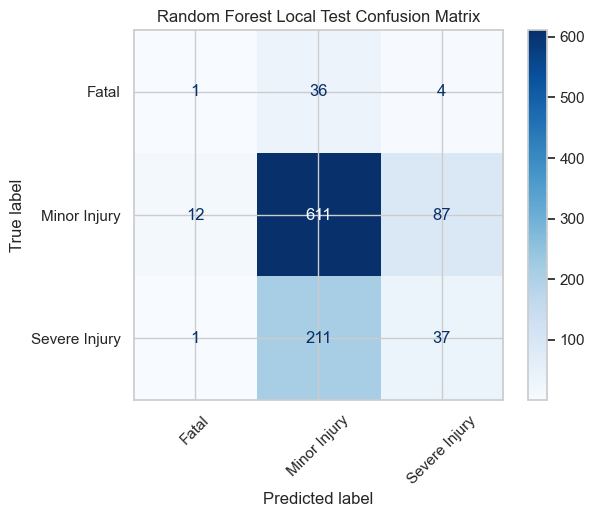

In [67]:
# Final local test evaluation for the selected Random Forest model.

y_test_pred_rf = evaluate_on_local_test(
    "Random Forest",
    best_rf_model,
    X_test_processed,
    y_test_encoded
)


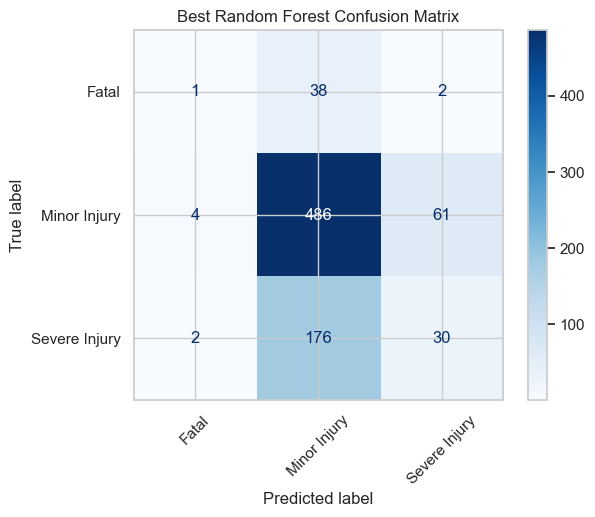

In [68]:
cm = confusion_matrix(y_valid, y_valid_pred_best_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Best Random Forest Confusion Matrix")
plt.show()

# Comment on Random Forest results

The Random Forest model achieved the best validation accuracy so far at 64.63%. However, the classification report shows that this improvement is mainly driven by the dominant Minor Injury class, which achieved a high recall of 0.88 and an F1-score of 0.78. The model performs poorly on the minority classes, especially Fatal, where recall is only 0.02 and the F1-score is 0.04. Severe Injury also has weak performance, with a recall of 0.14 and an F1-score of 0.20. Therefore, although Random Forest gives the highest accuracy, it is still biased toward the majority class and is not reliable for detecting the more severe accident outcomes. Macro F1-score should be considered alongside accuracy when comparing models.

# Logistic Regression

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import pandas as pd
import matplotlib.pyplot as plt

In [70]:
log_reg_model = LogisticRegression(
    max_iter=2000,
    class_weight=class_weight_dict,
    solver="lbfgs",
    random_state=42
)

log_reg_model.fit(X_train_processed, y_train)

LogisticRegression(class_weight={0: 6.4646464646464645, 1: 0.4837490551776266,
                                 2: 1.285140562248996},
                   max_iter=2000, random_state=42)

In [71]:
y_train_pred_lr = log_reg_model.predict(X_train_processed)
y_valid_pred_lr = log_reg_model.predict(X_valid_processed)

train_acc = accuracy_score(y_train, y_train_pred_lr)
valid_acc = accuracy_score(y_valid, y_valid_pred_lr)

print("Logistic Regression Training Accuracy:", train_acc)
print("Logistic Regression Validation Accuracy:", valid_acc)
print("Gap:", train_acc - valid_acc)

print("\nClassification Report:")
print(classification_report(
    y_valid,
    y_valid_pred_lr,
    target_names=label_encoder.classes_,
    zero_division=0
))

Logistic Regression Training Accuracy: 0.3465625
Logistic Regression Validation Accuracy: 0.33625
Gap: 0.010312500000000002

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.05      0.29      0.08        41
 Minor Injury       0.72      0.34      0.46       551
Severe Injury       0.26      0.35      0.30       208

     accuracy                           0.34       800
    macro avg       0.34      0.32      0.28       800
 weighted avg       0.56      0.34      0.40       800



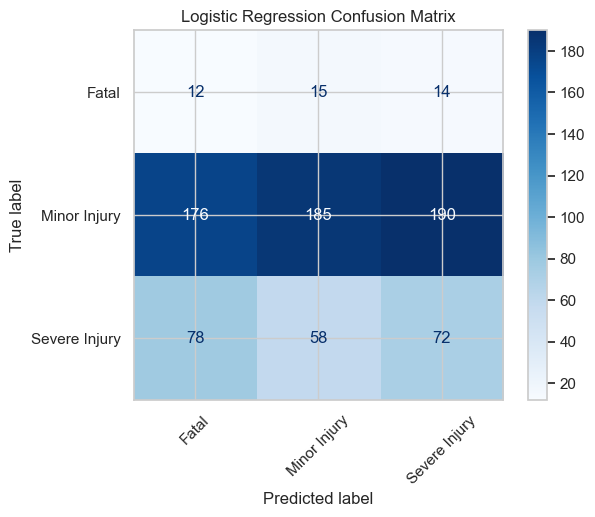

In [72]:
cm = confusion_matrix(y_valid, y_valid_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [73]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

lr_results = []

fatal_encoded = label_encoder.transform(["Fatal"])[0]
fatal_key = str(fatal_encoded)

for C in C_values:
    model = LogisticRegression(
        C=C,
        max_iter=3000,
        class_weight=class_weight_dict,
        solver="lbfgs",
        random_state=42
    )
    
    model.fit(X_train_processed, y_train)
    
    train_pred = model.predict(X_train_processed)
    valid_pred = model.predict(X_valid_processed)
    
    report = classification_report(
        y_valid,
        valid_pred,
        output_dict=True,
        zero_division=0
    )
    
    lr_results.append({
        "C": C,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "valid_accuracy": accuracy_score(y_valid, valid_pred),
        "gap": accuracy_score(y_train, train_pred) - accuracy_score(y_valid, valid_pred),
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "fatal_precision": report[fatal_key]["precision"],
        "fatal_recall": report[fatal_key]["recall"],
        "fatal_f1": report[fatal_key]["f1-score"]
    })

lr_results_df = pd.DataFrame(lr_results)

display(
    lr_results_df
    .sort_values(["macro_f1", "valid_accuracy"], ascending=False)
)

,C,train_accuracy,valid_accuracy,gap,macro_f1,weighted_f1,fatal_precision,fatal_recall,fatal_f1
3,1.0000,0.3466,0.3362,0.0103,0.2777,0.3964,0.0451,0.2927,0.0782
4,10.0000,0.3456,0.3362,0.0094,0.2777,0.3964,0.0451,0.2927,0.0782
5,100.0000,0.3456,0.3362,0.0094,0.2777,0.3964,0.0451,0.2927,0.0782
2,0.1000,0.3450,0.3362,0.0087,0.2775,0.3956,0.0455,0.2927,0.0787
1,0.0100,0.3291,0.3212,0.0078,0.2692,0.3785,0.0481,0.3171,0.0836
0,0.0010,0.2900,0.2863,0.0037,0.2520,0.3347,0.0569,0.4146,0.1000


In [74]:
best_lr_row = lr_results_df.sort_values(
    ["macro_f1", "valid_accuracy"],
    ascending=False
).iloc[0]

best_lr_row

C                 1.0000
train_accuracy    0.3466
valid_accuracy    0.3362
gap               0.0103
macro_f1          0.2777
weighted_f1       0.3964
fatal_precision   0.0451
fatal_recall      0.2927
fatal_f1          0.0782
Name: 3, dtype: float64

In [75]:
best_lr_model = LogisticRegression(
    C=best_lr_row["C"],
    max_iter=3000,
    class_weight=class_weight_dict,
    solver="lbfgs",
    random_state=42
)

best_lr_model.fit(X_train_processed, y_train)

y_train_pred_best_lr = best_lr_model.predict(X_train_processed)
y_valid_pred_best_lr = best_lr_model.predict(X_valid_processed)

print("Best Logistic Regression")
print("-" * 50)
print("C:", best_lr_row["C"])
print("Training Accuracy:", accuracy_score(y_train, y_train_pred_best_lr))
print("Validation Accuracy:", accuracy_score(y_valid, y_valid_pred_best_lr))
print("Gap:", accuracy_score(y_train, y_train_pred_best_lr) - accuracy_score(y_valid, y_valid_pred_best_lr))

print("\nClassification Report:")
print(classification_report(
    y_valid,
    y_valid_pred_best_lr,
    target_names=label_encoder.classes_,
    zero_division=0
))

Best Logistic Regression
--------------------------------------------------
C: 1.0
Training Accuracy: 0.3465625
Validation Accuracy: 0.33625
Gap: 0.010312500000000002

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.05      0.29      0.08        41
 Minor Injury       0.72      0.34      0.46       551
Severe Injury       0.26      0.35      0.30       208

     accuracy                           0.34       800
    macro avg       0.34      0.32      0.28       800
 weighted avg       0.56      0.34      0.40       800



## Logistic Regression Testing Phase


Logistic Regression Local Test Accuracy: 0.322

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.05      0.41      0.08        41
 Minor Injury       0.72      0.31      0.43       710
Severe Injury       0.25      0.34      0.29       249

     accuracy                           0.32      1000
    macro avg       0.34      0.36      0.27      1000
 weighted avg       0.58      0.32      0.38      1000



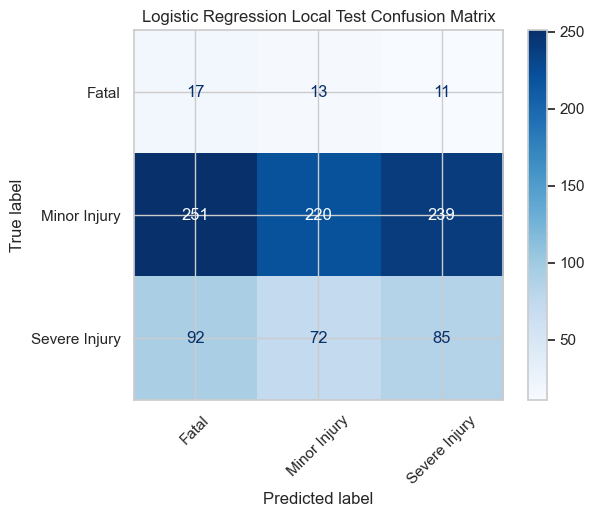

In [76]:
# Final local test evaluation for the selected Logistic Regression model.

y_test_pred_lr = evaluate_on_local_test(
    "Logistic Regression",
    best_lr_model,
    X_test_processed,
    y_test_encoded
)


# Comment on Logistic Regrission results

# Naive Bayes

In [77]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import pandas as pd
import matplotlib.pyplot as plt

In [78]:
X_train_nb = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_valid_nb = X_valid_processed.toarray() if hasattr(X_valid_processed, "toarray") else X_valid_processed
X_test_nb = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

print("Naive Bayes train shape:", X_train_nb.shape)
print("Naive Bayes valid shape:", X_valid_nb.shape)
print("Naive Bayes test shape:", X_test_nb.shape)

Naive Bayes train shape: (3200, 41)
Naive Bayes valid shape: (800, 41)
Naive Bayes test shape: (1000, 41)


In [79]:
nb_model = GaussianNB()

nb_model.fit(X_train_nb, y_train)

GaussianNB()

In [80]:
y_train_pred_nb = nb_model.predict(X_train_nb)
y_valid_pred_nb = nb_model.predict(X_valid_nb)

train_acc = accuracy_score(y_train, y_train_pred_nb)
valid_acc = accuracy_score(y_valid, y_valid_pred_nb)

print("Naive Bayes Training Accuracy:", train_acc)
print("Naive Bayes Validation Accuracy:", valid_acc)
print("Gap:", train_acc - valid_acc)

print("\nClassification Report:")
print(classification_report(
    y_valid,
    y_valid_pred_nb,
    target_names=label_encoder.classes_,
    zero_division=0
))

Naive Bayes Training Accuracy: 0.6515625
Naive Bayes Validation Accuracy: 0.635
Gap: 0.016562500000000036

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.09      0.05      0.06        41
 Minor Injury       0.69      0.89      0.77       551
Severe Injury       0.27      0.09      0.13       208

     accuracy                           0.64       800
    macro avg       0.35      0.34      0.32       800
 weighted avg       0.55      0.64      0.57       800



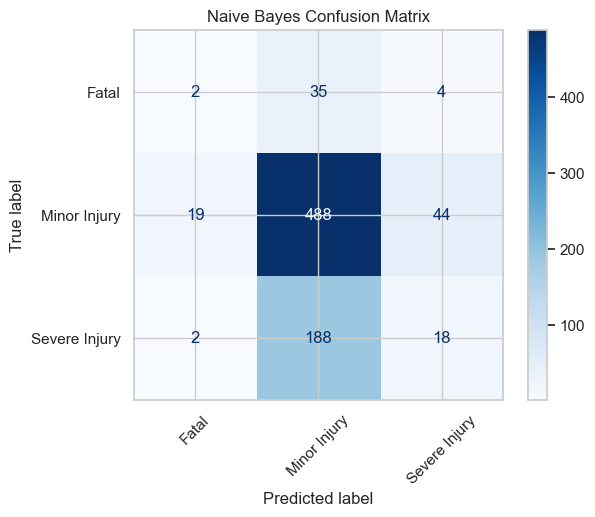

In [81]:
cm = confusion_matrix(y_valid, y_valid_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [82]:
var_smoothing_values = [
    1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4
]

nb_results = []

fatal_encoded = label_encoder.transform(["Fatal"])[0]
fatal_key = str(fatal_encoded)

for var_smoothing in var_smoothing_values:
    model = GaussianNB(var_smoothing=var_smoothing)
    
    model.fit(X_train_nb, y_train)
    
    train_pred = model.predict(X_train_nb)
    valid_pred = model.predict(X_valid_nb)
    
    report = classification_report(
        y_valid,
        valid_pred,
        output_dict=True,
        zero_division=0
    )
    
    nb_results.append({
        "var_smoothing": var_smoothing,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "valid_accuracy": accuracy_score(y_valid, valid_pred),
        "gap": accuracy_score(y_train, train_pred) - accuracy_score(y_valid, valid_pred),
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "fatal_precision": report[fatal_key]["precision"],
        "fatal_recall": report[fatal_key]["recall"],
        "fatal_f1": report[fatal_key]["f1-score"]
    })

nb_results_df = pd.DataFrame(nb_results)

display(
    nb_results_df
    .sort_values(["macro_f1", "valid_accuracy"], ascending=False)
)

,var_smoothing,train_accuracy,valid_accuracy,gap,macro_f1,weighted_f1,fatal_precision,fatal_recall,fatal_f1
0,0.0000,0.6516,0.6350,0.0166,0.3224,0.5700,0.0870,0.0488,0.0625
1,0.0000,0.6516,0.6350,0.0166,0.3224,0.5700,0.0870,0.0488,0.0625
2,0.0000,0.6516,0.6350,0.0166,0.3224,0.5700,0.0870,0.0488,0.0625
3,0.0000,0.6516,0.6350,0.0166,0.3224,0.5700,0.0870,0.0488,0.0625
4,0.0000,0.6516,0.6350,0.0166,0.3224,0.5700,0.0870,0.0488,0.0625
5,0.0000,0.6516,0.6350,0.0166,0.3224,0.5700,0.0870,0.0488,0.0625
6,0.0000,0.6516,0.6350,0.0166,0.3224,0.5700,0.0870,0.0488,0.0625
7,0.0000,0.6516,0.6350,0.0166,0.3224,0.5700,0.0870,0.0488,0.0625
8,0.0001,0.6519,0.6350,0.0169,0.3224,0.5700,0.0870,0.0488,0.0625


In [83]:
best_nb_row = nb_results_df.sort_values(
    ["macro_f1", "valid_accuracy"],
    ascending=False
).iloc[0]

best_nb_row

var_smoothing     0.0000
train_accuracy    0.6516
valid_accuracy    0.6350
gap               0.0166
macro_f1          0.3224
weighted_f1       0.5700
fatal_precision   0.0870
fatal_recall      0.0488
fatal_f1          0.0625
Name: 0, dtype: float64

In [84]:
best_nb_model = GaussianNB(
    var_smoothing=best_nb_row["var_smoothing"]
)

best_nb_model.fit(X_train_nb, y_train)

y_train_pred_best_nb = best_nb_model.predict(X_train_nb)
y_valid_pred_best_nb = best_nb_model.predict(X_valid_nb)

print("Best Naive Bayes")
print("-" * 50)
print("var_smoothing:", best_nb_row["var_smoothing"])
print("Training Accuracy:", accuracy_score(y_train, y_train_pred_best_nb))
print("Validation Accuracy:", accuracy_score(y_valid, y_valid_pred_best_nb))
print("Gap:", accuracy_score(y_train, y_train_pred_best_nb) - accuracy_score(y_valid, y_valid_pred_best_nb))

print("\nClassification Report:")
print(classification_report(
    y_valid,
    y_valid_pred_best_nb,
    target_names=label_encoder.classes_,
    zero_division=0
))

Best Naive Bayes
--------------------------------------------------
var_smoothing: 1e-12
Training Accuracy: 0.6515625
Validation Accuracy: 0.635
Gap: 0.016562500000000036

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.09      0.05      0.06        41
 Minor Injury       0.69      0.89      0.77       551
Severe Injury       0.27      0.09      0.13       208

     accuracy                           0.64       800
    macro avg       0.35      0.34      0.32       800
 weighted avg       0.55      0.64      0.57       800



## Naive Bayes Testing Phase


Naive Bayes Local Test Accuracy: 0.673

Classification Report:
               precision    recall  f1-score   support

        Fatal       0.00      0.00      0.00        41
 Minor Injury       0.72      0.92      0.80       710
Severe Injury       0.38      0.08      0.14       249

     accuracy                           0.67      1000
    macro avg       0.36      0.33      0.31      1000
 weighted avg       0.60      0.67      0.61      1000



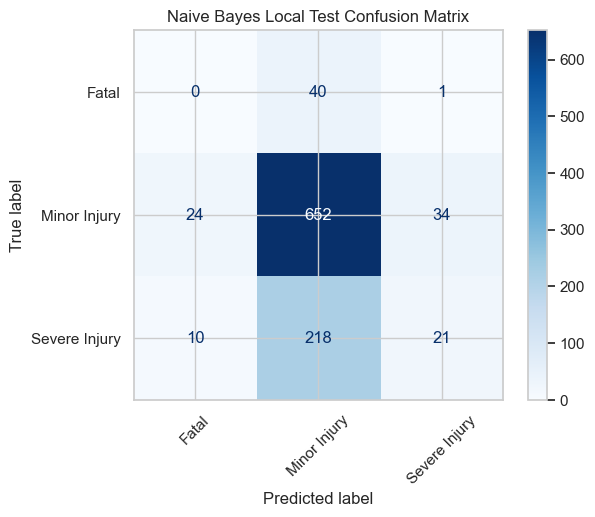

In [85]:
# Final local test evaluation for the selected Naive Bayes model.
# GaussianNB uses the dense Naive Bayes test matrix.

y_test_pred_nb = evaluate_on_local_test(
    "Naive Bayes",
    best_nb_model,
    X_test_nb,
    y_test_encoded
)


# Comment on Naive Bayes results

The Naive Bayes model achieved a validation accuracy of 63.5%, which is relatively high compared to several other models. However, the classification report shows that this performance is mainly driven by the dominant Minor Injury class, which achieved a recall of 0.89 and an F1-score of 0.77. In contrast, the model performs poorly on the minority classes, with an F1-score of only 0.06 for Fatal and 0.13 for Severe Injury. The small train-validation gap suggests that the model is not overfitting, but the low macro F1-score of 0.32 indicates poor balanced performance. Therefore, Naive Bayes is reasonably good at identifying Minor Injury cases, but it is not reliable for detecting severe or fatal accident outcomes.

# Comparison across all models

The model comparison shows that Random Forest achieved the highest validation accuracy of 64.62% and the highest weighted F1-score of 0.5891. However, this performance is mainly driven by the dominant Minor Injury class, while its Fatal Recall is extremely low at 0.0244. KNN achieved the highest Macro F1-score of 0.3540, suggesting that it provides the most balanced performance across the three classes, although its overall accuracy is lower. Logistic Regression had the lowest accuracy, but it achieved the highest Fatal Recall of 0.2927, meaning it is more sensitive to fatal cases, although with poor precision. Overall, Random Forest is the best model in terms of accuracy, but KNN is preferable if balanced class performance is prioritized. Since the dataset is imbalanced and Fatal/Severe Injury cases are safety-critical, Macro F1-score and class-specific recall should be considered more important than accuracy alone

# Local Test Performance Comparison

This table compares the final selected models on the local labeled test set. These results should be interpreted as a final holdout evaluation and should not be used to tune hyperparameters.


In [86]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd

def evaluate_model(model_name, y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )
    
    fatal_id = label_encoder.transform(["Fatal"])[0]
    minor_id = label_encoder.transform(["Minor Injury"])[0]
    severe_id = label_encoder.transform(["Severe Injury"])[0]
    
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted"),
        
        "Fatal Precision": report[str(fatal_id)]["precision"],
        "Fatal Recall": report[str(fatal_id)]["recall"],
        "Fatal F1": report[str(fatal_id)]["f1-score"],
        
        "Minor Injury Precision": report[str(minor_id)]["precision"],
        "Minor Injury Recall": report[str(minor_id)]["recall"],
        "Minor Injury F1": report[str(minor_id)]["f1-score"],
        
        "Severe Injury Precision": report[str(severe_id)]["precision"],
        "Severe Injury Recall": report[str(severe_id)]["recall"],
        "Severe Injury F1": report[str(severe_id)]["f1-score"]
    }

In [87]:
if y_test_encoded is not None:
    test_model_results = []

    test_model_results.append(evaluate_model("KNN", y_test_encoded, y_test_pred_knn))
    test_model_results.append(evaluate_model("Decision Tree", y_test_encoded, y_test_pred_dt))
    test_model_results.append(evaluate_model("Random Forest", y_test_encoded, y_test_pred_rf))
    test_model_results.append(evaluate_model("Logistic Regression", y_test_encoded, y_test_pred_lr))
    test_model_results.append(evaluate_model("Naive Bayes", y_test_encoded, y_test_pred_nb))

    test_results_df = pd.DataFrame(test_model_results)

    test_results_df_sorted = test_results_df.sort_values(
        ["Macro F1", "Accuracy"],
        ascending=False
    )

    display(test_results_df_sorted)
else:
    print("No local test labels available, so test metrics cannot be computed.")


,Model,Accuracy,Macro F1,Weighted F1,Fatal Precision,Fatal Recall,Fatal F1,Minor Injury Precision,Minor Injury Recall,Minor Injury F1,Severe Injury Precision,Severe Injury Recall,Severe Injury F1
2,Random Forest,0.6490,0.3373,0.6037,0.0714,0.0244,0.0364,0.7121,0.8606,0.7793,0.2891,0.1486,0.1963
0,KNN,0.5610,0.3318,0.5614,0.0545,0.0732,0.0625,0.7069,0.7099,0.7084,0.2328,0.2169,0.2245
4,Naive Bayes,0.6730,0.3142,0.6058,0.0000,0.0000,0.0000,0.7165,0.9183,0.8049,0.3750,0.0843,0.1377
3,Logistic Regression,0.3220,0.2698,0.3837,0.0472,0.4146,0.0848,0.7213,0.3099,0.4335,0.2537,0.3414,0.2911
1,Decision Tree,0.3290,0.2649,0.3931,0.0308,0.2439,0.0546,0.7196,0.3254,0.4481,0.2486,0.3534,0.2919


In [88]:
# Sort models by Macro F1 for consistent plotting
test_plot_df = test_results_df.sort_values(
    ["Macro F1", "Accuracy"],
    ascending=False
).copy()

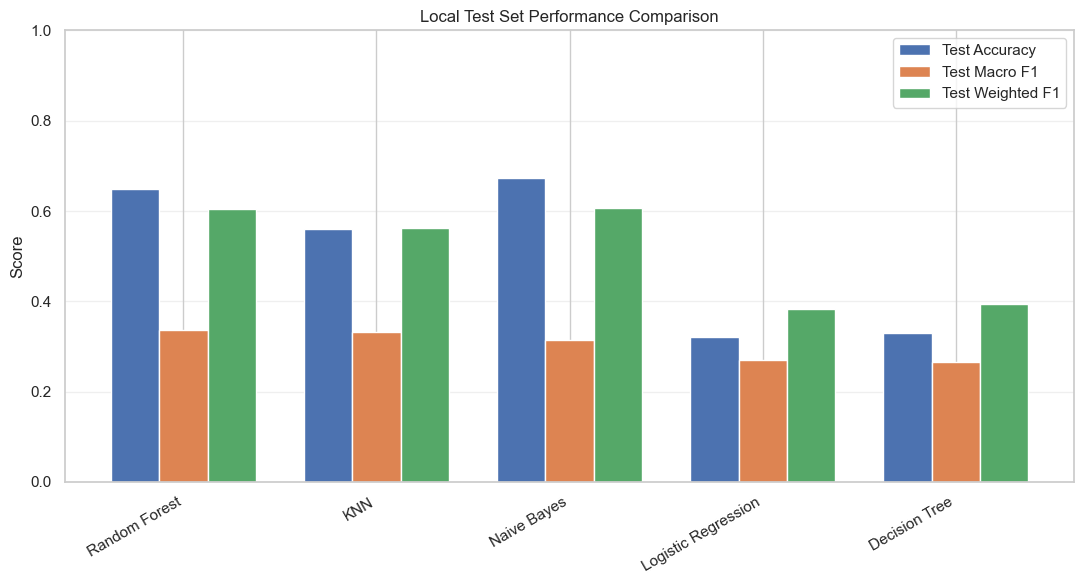

In [89]:
plt.figure(figsize=(11, 6))

x = range(len(test_plot_df))

plt.bar(
    [i - 0.25 for i in x],
    test_plot_df["Accuracy"],
    width=0.25,
    label="Test Accuracy"
)

plt.bar(
    x,
    test_plot_df["Macro F1"],
    width=0.25,
    label="Test Macro F1"
)

plt.bar(
    [i + 0.25 for i in x],
    test_plot_df["Weighted F1"],
    width=0.25,
    label="Test Weighted F1"
)

plt.xticks(x, test_plot_df["Model"], rotation=30, ha="right")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Local Test Set Performance Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Comment on performance across all models


The model comparison shows that Random Forest achieved the highest validation accuracy of 64.62% and the highest weighted F1-score of 0.5891. However, this performance is mainly driven by the dominant Minor Injury class, while its Fatal Recall is extremely low at 0.0244. KNN achieved the highest Macro F1-score of 0.3540, suggesting that it provides the most balanced performance across the three classes, although its overall accuracy is lower. Logistic Regression had the lowest accuracy, but it achieved the highest Fatal Recall of 0.2927, meaning it is more sensitive to fatal cases, although with poor precision. Overall, Random Forest is the best model in terms of accuracy, but KNN is preferable if balanced class performance is prioritized. Since the dataset is imbalanced and Fatal/Severe Injury cases are safety-critical, Macro F1-score and class-specific recall should be considered more important than accuracy alone